# Context
For the purpose of this notebook, we will simulate being in a company that has recently implented a Advertisement type of marketing strategy to engage more people in the company's products and services. However, using ads for the company's products and services can cost us more compared to psa, that's why our company has been wondering whether or not this type of implementation is effective or not in converting customers compared to our old strategy of exposing people to Public Service Announcements (PSAs). To inspect this, the company has decided to run an experimental test where a certain number of people are exposed to psa, while the other is exposed to ads. To ensure consistency in the study, the company has made sure that the placement of ads and psa is identical, eliminating the positioning factor in determining whether ads is more effective than psa. 

# Goal
Our job as a Data Scientist is to analyze whether or not this ad implementation is better than our original strategy of using public service announcements. We must be able to evaluate the effectiveness of ads relative to psa, which is our baseline. We must also be able to determine the magnitude by which it is more, or less, effective and then, based on our conclusion, recommend actions that the company should take to optimize revenue.

# Method
To achieve our goal, we will conduct A/B Testing, using Ads as our experimental or treatment group, while psa is our control or baseline group. First, we will process the data to fit the input for our analysis, then, determine whether one or the other is more effective, particularly in converting customers. Afterwards, we then determine whether this finding is significant and, if so then, by how much. We may also draw factors that may affect these analysis, such as the number of people engaged with each type of marketing.

# Data
For this simulation, we will utilize a dataset from Kaggle titled "Marketing A/B testing dataset" by FavioVázquez. This dataset contains data regarding user conversion depending on test group. The columns are detailed as follows:

- user id: User ID (unique)
- test group: If "ad" the person saw the advertisement, if "psa" they only saw the public service announcement
- converted: If a person bought the product then True, else is False
- total ads: Amount of ads seen by person
- most ads day: Day that the person saw the biggest amount of ads
- most ads hour: Hour of day that the person saw the biggest amount of ads

# Libraries

In [1]:
import pandas as pd
import sklearn.utils.stats as stats
import os
import numpy as np
from scipy.stats.contingency import chi2_contingency
from scipy.stats import chi2
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Preparing Data

### Downloading Data

In [2]:
os.environ['KAGGLEHUB_CACHE'] = os.curdir

if not os.path.isdir('datasets'):
    import kagglehub
    path = kagglehub.dataset_download("faviovaz/marketing-ab-testing")
else:
    path = os.path.join('datasets','faviovaz','marketing-ab-testing','versions','1')
    
path = os.path.join(path, 'marketing_AB.csv')
print("Path to dataset files:", path)

Path to dataset files: datasets\faviovaz\marketing-ab-testing\versions\1\marketing_AB.csv


### Inspecting Data

In [3]:
df = pd.read_csv(path).drop('Unnamed: 0', axis = 1)
df

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14
...,...,...,...,...,...,...
588096,1278437,ad,False,1,Tuesday,23
588097,1327975,ad,False,1,Tuesday,23
588098,1038442,ad,False,3,Tuesday,23
588099,1496395,ad,False,1,Tuesday,23


In [4]:
df.describe()

,user id,total ads,most ads hour
count,5.881010e+05,588101.000000,588101.000000
mean,1.310692e+06,24.820876,14.469061
std,2.022260e+05,43.715181,4.834634
min,9.000000e+05,1.000000,0.000000
25%,1.143190e+06,4.000000,11.000000
50%,1.313725e+06,13.000000,14.000000
75%,1.484088e+06,27.000000,18.000000
max,1.654483e+06,2065.000000,23.000000


In [5]:
df['test group'].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [6]:
df[['test group','converted']].sample(10)

,test group,converted
249481,ad,False
526264,ad,False
65662,ad,False
370674,ad,False
491824,ad,False
148185,ad,False
432525,ad,False
398193,ad,False
36804,ad,False
50388,ad,False


In [7]:
df['most ads hour'].value_counts()

most ads hour
13    47655
12    47298
11    46210
14    45648
15    44683
10    38939
16    37567
17    34988
18    32323
9     31004
19    30352
21    29976
20    28923
22    26432
23    20166
8     17627
7      6405
0      5536
2      5333
1      4802
3      2679
6      2068
5       765
4       722
Name: count, dtype: int64

# Hypothesis Testing

- Null Hypothesis = There is no significant change
- Alternative Hypothesis = There is a significant change

In [8]:
grouped_df = df.groupby('test group').agg({'converted':'sum', 'user id':'count','total ads':'sum', 'most ads hour':'mean'})
grouped_df

,converted,user id,total ads,most ads hour
test group,,,,
ad,14423,564577,14014701,14.475900
psa,420,23524,582481,14.304923


In [9]:
grouped_df['conversion rate'] = grouped_df['converted']/grouped_df['user id']
grouped_df

,converted,user id,total ads,most ads hour,conversion rate
test group,,,,,
ad,14423,564577,14014701,14.475900,0.025547
psa,420,23524,582481,14.304923,0.017854


In [10]:
contingency_table = pd.crosstab(df['test group'], df['converted'])
contingency_table

converted,False,True
test group,,
ad,550154,14423
psa,23104,420


In [11]:
chi2, p, dof, expected = chi2_contingency(contingency_table)
p

np.float64(1.9989623063390075e-13)

In [12]:
alpha = 0.05
decision = 'There is a significant difference' if alpha > p else 'There is no significant difference'

print(decision)

There is a significant difference


Using this, we can infer that there is a significant difference. However, we still have no grounds on how large this difference is between them. To determine this, we'll calculate the lift, which is the difference of using ad over psa relative to psa, since psa is our baseline.

In [13]:
# Calculate lift
ad_conv = grouped_df['conversion rate']['ad']
psa_conv = grouped_df['conversion rate']['psa']

absolute_lift = round(
    (ad_conv - psa_conv) * 100, 
    2
)

relative_lift = round(
    absolute_lift/psa_conv * 100,
    2
)
print(f'{decision} with a relative lift of {relative_lift}% and an absolute lift of {absolute_lift}% conversion rate')

There is a significant difference with a relative lift of 4312.73% and an absolute lift of 0.77% conversion rate


Using the lift, we can scale how effective (or ineffective) our treatment is compared to our control/baseline. As shown above, the magnitude of the lift is positive. Relative to our baseline, it is 43.13% effective. However, through the absolute lift, we can see that the absolute increase in conversion rate is only around 0.77% conversion rate, meaning that, although effective and by nearly almost half of the baseline's performance, the conversion rate absolute difference remains quite small, with only an increase of 0.77% chance of conversion per customer in exposure to ad over that of psa.

Nevertheless, it is evident that the usage of ads over psa does improve conversion rate, albeit by a slight margin. Regardless of this, ad remains more effective than psa, having a little less under half of the baseline's conversion rate.

# Visualizing

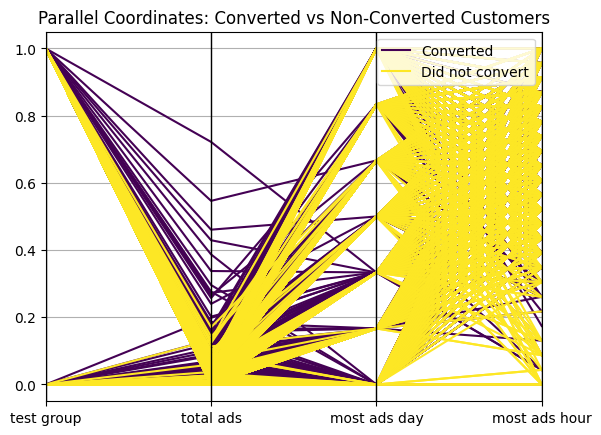

In [14]:
n_samples = 2000

# Prepare data
plot_df = df.copy()

plot_df['test group'] = plot_df['test group'].map({'ad': 1, 'psa': 0})
plot_df['most ads day'] = plot_df['most ads day'].map({'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 
                                                       'Friday': 4, 'Saturday': 5, 'Sunday': 6})
plot_df = plot_df.drop('user id', axis = 1) # irrelevant

# Min Max Norm
minmax = MinMaxScaler().set_output(transform = 'pandas')
plot_df = minmax.fit_transform(plot_df)
plot_df['converted'] = plot_df['converted'].map({0:'Did not convert', 1:'Converted'})

# Stratification
converted_df = plot_df.loc[plot_df['converted'] == 'Converted', :]
non_converted_df = plot_df.loc[plot_df['converted'] == 'Did not convert', :]

combined_samples = pd.concat([
    converted_df.sample(n_samples//2),
    non_converted_df.sample(n_samples//2)
], axis = 0)

plt.figure()
parallel_coordinates(
    combined_samples,
    class_column='converted',
    colormap = 'viridis'
)
plt.title("Parallel Coordinates: Converted vs Non-Converted Customers")
plt.show()

We've normalized the plot to set the scales to a similar range. The 1 and 0 in test group represents ad and psa respectively. The rest of the columns are the percentage normalized values with respect to the ranges of their corresponding variables (i.e.: a 1 in most ads hour would be 23 implying 23:00 or rather 11:00 PM, and a 0 would be a 0:00 which would be 12:00 AM.). The lines separate those Customers that converted (Violet) alongside those that did not convert (Yellow).

The plot stratifies both conversion groups (converted vs non-converted) by drawing samples from both, then combining them into one merged dataset, making it so that both sides are represented in the plot. As the plot cannot process all the information at once, this method makes it so that all the information can be derived by running the code multiple times and noticing the changes in both groups.

After running this code multiple times, we can infer that majority of the variables act arbitrarily towards both groups, with the exclusion of total ads. Despite running the code multiple times, a large majority of the converted group comes from having a relatively high total ads value of around 0.4, implying that those Customers that converted have been exposed to about 40% of total ads. Additionally, it is also notable to state that converted Customers generally seem to be from the ad test group rather than the psa, supporting the effectiveness of the ad approach compared to psa, as demonstrated by our test earlier.

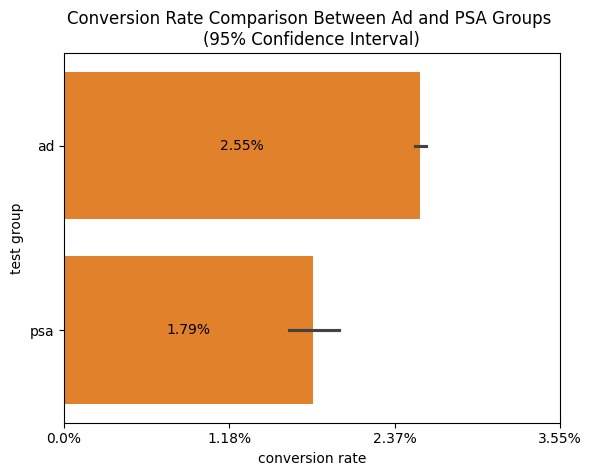

In [15]:
gap = 0.01
upper_limit = max(grouped_df['conversion rate']) + gap
lower_limit = 0
xticks = np.linspace(lower_limit, upper_limit, num = 4)

bars = sns.barplot(grouped_df['conversion rate'], orient = 'h')

sns.barplot(data = df, y = "test group", x = "converted", orient = 'h', errorbar = ('ci', 95))
plt.xticks(xticks, labels = [f'{round(x*100, 2)}%' for x in xticks])
plt.bar_label(bars.containers[0], labels = [f'{round(x*100, 2)}%' for x in grouped_df['conversion rate']], label_type = 'center')
plt.title('Conversion Rate Comparison Between Ad and PSA Groups \n(95% Confidence Interval)')
plt.show()

Inspecting the conversion rate using a horizontal bar plot, we see that ad is significantly better than psa. With a confidence interval of 95%, we can see that even the best estimate for the true conversion rate of the population of the psa test group cannot reach or outperform that of the ad test group, displaying the wide gap in terms of conversion rate.

We've seen that the ads significantly outperforms psa; however, we've yet to see information that can benefit the company in some way. Yes, we've identified that ads are a better method compared to psa, but we have yet to see a distinct pattern aside from this. Without it, the company will be blindly implementing ads without proper guidance. Let's try looking at another variable in our dataset: Time.

In [16]:
ads_hours = pd.DataFrame(df.loc[df['test group'] == 'ad','most ads hour'].value_counts().sort_index()).reset_index(drop = True)
ads_hours

,count
0,5309
1,4615
2,5152
3,2590
4,694
5,742
6,1985
7,6168
8,16968
9,29802


Above is the counts of each user in our dataset where they have entered what specific hour did they encounter the most ads in their day. Using this, we can infer what range of hours is most effective in exposing the most customers using the least amount of expense by covering only a specified time range in which our ad will be shown.

But, this dataset is a bit hard to interpret, let's plot it inside a bar plot and inspect its behavior there.

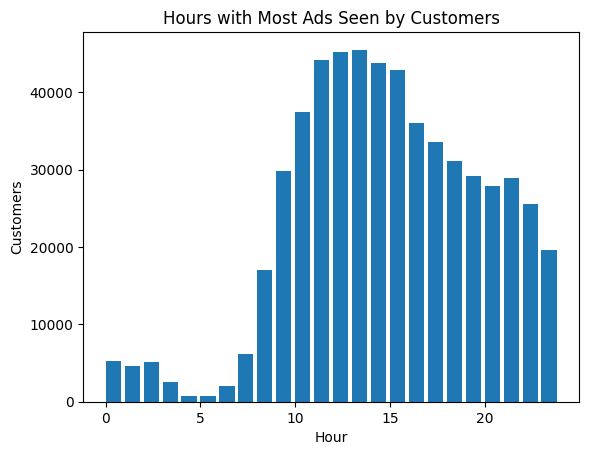

In [17]:
plt.bar(ads_hours.index, ads_hours['count'], align = 'edge')
plt.title('Hours with Most Ads Seen by Customers')
plt.ylabel('Customers')
plt.xlabel('Hour')
plt.show()

Using this barplot, we can already see the hours that majority of the customers have been exposed to the most ads from the company.

This bar plot is good, but it can be better. Time is a cyclic pattern that repeats or loops, so, using a radial/polar plot would make much more sense in visualizing this information.

In addition to creating this polar plot, we'll create a color mapping that applies a color based on the value of an index (or hour in this case) depending on how many Customers have found that specific hour as the most engaging or most exposed hour to ads, doing so lets the plot become more intuitive.

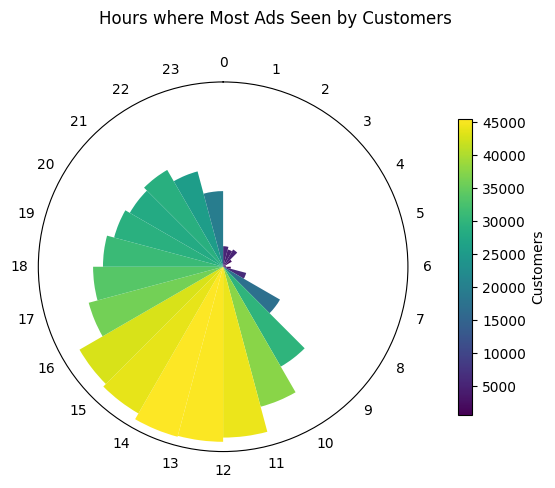

In [18]:
# Configure Colormap for barplot
norm = plt.Normalize(ads_hours.min(), ads_hours.max())
cmap = plt.cm.viridis
colors = cmap(norm(ads_hours['count']))

# Creating the plot
fig, ax = plt.subplots(subplot_kw = {'projection':'polar'})

# Position for x relative to a circle
theta = np.linspace(0, 2*np.pi, 24, endpoint = False)

# Plot count relative to positions in circle
ax.bar(theta, ads_hours['count'], width = (2*np.pi)/24, align = 'edge', color = colors)

# Configuring the label for the colors by creating a color bar
scale_map = plt.cm.ScalarMappable(cmap = cmap, norm = norm)

cbar = plt.colorbar(scale_map, ax = ax, pad = 0.1, shrink = 0.8)
cbar.set_label('Customers')

# Styling
fig.suptitle('Hours where Most Ads Seen by Customers', y= 1.03)
ax.get_yaxis().set_visible(False)
ax.xaxis.grid(False)
ax.yaxis.grid(True)
ax.set_xticks(theta, ads_hours.index)
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
plt.show()

The polar plot makes our data more interpretable. The color highlights which areas are the hours that Customers are most exposed to ads. Looking at the plot, we can infer that the ranges 10 to 16 are the most common hours that majority of the Customers have reported seeing the most ads in their day. In standard time, the range 10:00 to 16:00 is equal to 10:00 AM to 4:00 PM, which is around the afternoon where majority of the people are resting or taking their lunch. Using this, we can recommend the company to focus on getting our ads presented within this time range, as it is the hours that majority of the Customers are exposed to the most ads.

With this, we now have a specified range. But, this could be better as we still have another variable that we can use in our dataset: Day of the Week.

Using this variable, we can narrow down which day of the week should the company implement their optimal ad placement, further optimizing costs for customer exposure.

In [19]:
ads_days = pd.DataFrame(df.loc[df['test group'] == 'ad', 'most ads day'].value_counts()).reset_index()

# Days of Week starting with Sunday
dow = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']

# Implement order into categorical column
ads_days['most ads day'] = pd.Categorical(ads_days['most ads day'], dow, ordered = True) 
ads_days.sort_values('most ads day')

,most ads day,count
2,Sunday,82332
1,Monday,83571
6,Tuesday,74572
5,Wednesday,77418
3,Thursday,79077
0,Friday,88805
4,Saturday,78802


Much like before, it would be better to visualize this data in a plot so that we may be able to infer from it much easier.

For this plot, we'll utilize a barplot to separate the categories (day of the week) from each other while still comparing the number of customers that have seen the most ads on that day (height of bars). Additionally, we'll add color to the bars that dictate how high the number of customers are in that specific day of the week, which will help in making the plot more intuitive and acts like another layer of information that highlights the margin of each bar height from each other. To avoid label overlap, we'll also rotate the x label to a 45 degree angle so that it remains quite readable without much effort, but completely avoids label overlap.

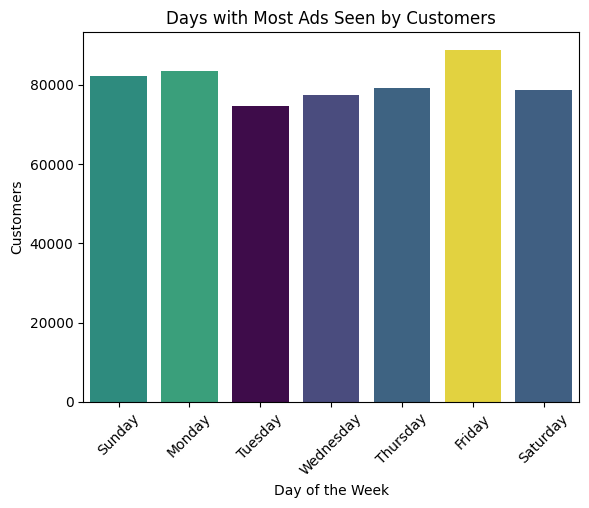

In [20]:
sns.barplot(ads_days, x = 'most ads day', y = 'count', hue = 'count', legend = False, order = dow, palette = 'viridis')
plt.title('Days with Most Ads Seen by Customers')
plt.ylabel('Customers')
plt.xlabel('Day of the Week')
plt.xticks(rotation = 45)
plt.show()

Looking at the plot, it seems that majority of the customers have seen ads the most on Fridays, followed by Monday and Sunday. These days are generally the off-days for many: days that many people are off work or are only starting to work. 

Fridays are the top most reported day of the week where majority of the customers have seen ads, likely due to it being the end of the work week, where many people opt to rest and take it easy. 

Sunday and Monday are quite lower than that of Friday which means that majority of the customers still see ads before or after going to work on Monday, and likely during their free time on Sundays. 

Saturday is also significantly lower than all three of them, implying that this day may be dedicated to the customer's rest day, where they hardly interact with the ads and are simply relaxing by indulging in their own separate hobbies and interests.

In contrast, the middle of the work week, Tuesday all the way to Thursday, are the days with the lowest reported ads seen by customers within the week, presumably due to majority of the customers being busy with work, resulting in many often not hearing the ad or outright avoiding it to reduce distractions and focus more on their work.

Using this information, we can likely tell the company to implement the otpimal time range to the optimal days of the week, significantly improving our ad engagement whilst minimizing costs for ad marketing and placement.

However, we can go even deeper in this analysis by combining what we know in both variables and inspecting the time per day of the week. This allows us to narrow down the different time ranges that customers on that particular day see the most ads, since it might be possible that the optimal time range for each day differ.

To do this, we'll simply redraw the polar plot we used to visualize time, but this time, we will narrow down our dataset to our specified day of the week.

In [30]:
df.loc[
    (df['test group'] == 'ad') &
    (df['most ads day'] == day),
    'most ads hour'
].value_counts()

most ads hour
12    6744
13    6678
11    6433
15    6357
14    6039
16    5592
17    5432
10    5159
18    5038
20    4567
19    4449
9     4365
21    4244
22    3934
23    2550
8     2412
0      820
7      760
2      709
1      531
3      316
6      262
5       92
4       88
Name: count, dtype: int64

In [63]:
day = 'Monday'

ads_hours_day = pd.DataFrame(
    df.loc[
    (df['test group'] == 'ad') &
    (df['most ads day'] == day),
    'most ads hour'
    ].value_counts()
).sort_values('most ads hour')

ads_hours_day


,count
most ads hour,
0,820
1,531
2,709
3,316
4,88
5,92
6,262
7,760
8,2412


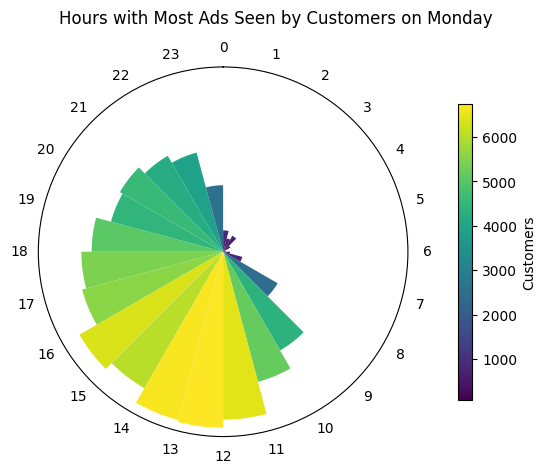

In [ ]:
fig, ax = plt.subplots(subplot_kw = {'projection':'polar'})

theta = np.linspace(0, 2*np.pi, 24, endpoint = False)

norm = plt.Normalize(ads_hours_day['count'].min(), ads_hours_day['count'].max())
cm = plt.cm.viridis
colors = cm(norm(ads_hours_day['count']))

scale_map = plt.cm.ScalarMappable(norm, cm)
cbar = plt.colorbar(scale_map, ax = ax, pad = 0.1, shrink = 0.8)
cbar.set_label('Customers')


ax.bar(theta, ads_hours_day['count'], width = (2*np.pi)/24, align = 'edge', color = colors)
fig.suptitle(f'Hours with Most Ads Seen by Customers on {day}', y = 1)
ax.yaxis.set_visible(False)
ax.xaxis.grid(False)
ax.set_xticks(theta, ads_hours_day.index)
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
plt.show()

In [ ]:
def polar_plot(day: str, colormap: plt.cm = plt.cm.viridis, cbar_pad: float = 0.1,
               cbar_shrink: float = 0.8, title_offset: int | float = 1):
    ads_hours_day = pd.DataFrame(
        df.loc[
        (df['test group'] == 'ad') &
        (df['most ads day'] == day),
        'most ads hour'
        ].value_counts()
    ).sort_values('most ads hour')
    
    fig, ax = plt.subplots(subplot_kw = {'projection':'polar'})

    theta = np.linspace(0, 2*np.pi, 24, endpoint = False)

    norm = plt.Normalize(ads_hours_day['count'].min(), ads_hours_day['count'].max())
    cm = colormap
    colors = cm(norm(ads_hours_day['count']))

    scale_map = plt.cm.ScalarMappable(norm, cm)
    cbar = plt.colorbar(scale_map, ax = ax, pad = cbar_pad, shrink = cbar_shrink)
    cbar.set_label('Customers')


    ax.bar(theta, ads_hours_day['count'], width = (2*np.pi)/24, align = 'edge', color = colors)
    fig.suptitle(f'Hours with Most Ads Seen by Customers on {day}', y = title_offset)
    ax.yaxis.set_visible(False)
    ax.xaxis.grid(False)
    ax.set_xticks(theta, ads_hours_day.index)
    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)
    plt.show()
    
    return


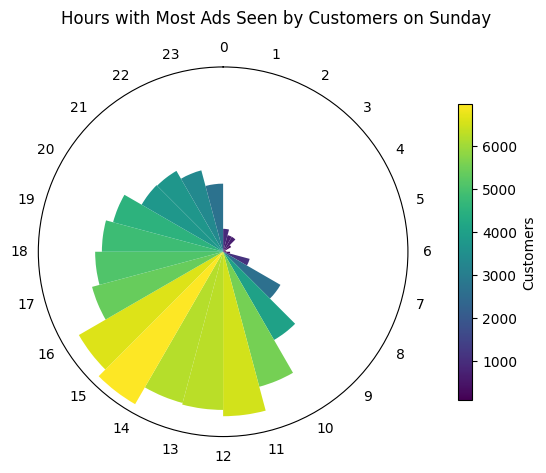

In [93]:
polar_plot('Sunday')